## Imports

In [1]:
from typing import List, Tuple, Optional, Dict, NamedTuple, Union, Callable
import itertools
import os
import string
from pathlib import Path

import numpy as np
import torch
from scipy.spatial.distance import squareform, pdist, cdist
import matplotlib.pyplot as plt
import matplotlib as mpl
from Bio import SeqIO
import biotite.structure as bs

from biotite.structure.io.pdb import PDBFile, get_structure

from biotite.database import rcsb

from tqdm import tqdm
import pandas as pd

import esm

torch.set_grad_enabled(False)

## Define Functions

### Parsing alignments

In [2]:
# This is an efficient way to delete lowercase characters and insertion characters from a string
deletekeys = dict.fromkeys(string.ascii_lowercase)
deletekeys["."] = None
deletekeys["*"] = None
translation = str.maketrans(deletekeys)

def read_sequence(filename: str) -> Tuple[str, str]:
    """ Reads the first (reference) sequences from a fasta or MSA file."""
    record = next(SeqIO.parse(filename, "fasta"))
    return record.description, str(record.seq)

def remove_insertions(sequence: str) -> str:
    """ Removes any insertions into the sequence. Needed to load aligned sequences in an MSA. """
    return sequence.translate(translation)

def read_msa(filename: str) -> List[Tuple[str, str]]:
    """ Reads the sequences from an MSA file, automatically removes insertions."""
    return [(record.description, remove_insertions(str(record.seq))) for record in SeqIO.parse(filename, "fasta")]

### Converting structures to contacts

There are many ways to define a protein contact. Here we're using the definition of 8 angstroms between carbon beta atoms. Note that the position of the carbon beta is imputed from the position of the N, CA, and C atoms for each residue.

In [3]:
def extend(a, b, c, L, A, D):
    """
    input:  3 coords (a,b,c), (L)ength, (A)ngle, and (D)ihedral
    output: 4th coord
    """

    def normalize(x):
        return x / np.linalg.norm(x, ord=2, axis=-1, keepdims=True)

    bc = normalize(b - c)
    n = normalize(np.cross(b - a, bc))
    m = [bc, np.cross(n, bc), n]
    d = [L * np.cos(A), L * np.sin(A) * np.cos(D), -L * np.sin(A) * np.sin(D)]
    return c + sum([m * d for m, d in zip(m, d)])


def contacts_from_pdb(
    structure: bs.AtomArray,
    distance_threshold: float = 8.0,
    chain: Optional[str] = None,
) -> np.ndarray:
    mask = ~structure.hetero
    if chain is not None:
        mask &= structure.chain_id == chain

    N = structure.coord[mask & (structure.atom_name == "N")]
    CA = structure.coord[mask & (structure.atom_name == "CA")]
    C = structure.coord[mask & (structure.atom_name == "C")]

    Cbeta = extend(C, N, CA, 1.522, 1.927, -2.143)
    dist = squareform(pdist(Cbeta))
    
    contacts = dist < distance_threshold
    contacts = contacts.astype(np.int64)
    contacts[np.isnan(dist)] = -1
    return contacts

### Compute contact precisions

In [6]:
def compute_precisions(
    predictions: torch.Tensor,
    targets: torch.Tensor,
    src_lengths: Optional[torch.Tensor] = None,
    minsep: int = 6,
    maxsep: Optional[int] = None,
    override_length: Optional[int] = None,  # for casp
):
    if isinstance(predictions, np.ndarray):
        predictions = torch.from_numpy(predictions)
    if isinstance(targets, np.ndarray):
        targets = torch.from_numpy(targets)
    if predictions.dim() == 2:
        predictions = predictions.unsqueeze(0)
    if targets.dim() == 2:
        targets = targets.unsqueeze(0)
    override_length = (targets[0, 0] >= 0).sum()

    # Check sizes
    if predictions.size() != targets.size():
        raise ValueError(
            f"Size mismatch. Received predictions of size {predictions.size()}, "
            f"targets of size {targets.size()}"
        )
    device = predictions.device

    batch_size, seqlen, _ = predictions.size()
    seqlen_range = torch.arange(seqlen, device=device)

    sep = seqlen_range.unsqueeze(0) - seqlen_range.unsqueeze(1)
    sep = sep.unsqueeze(0)
    valid_mask = sep >= minsep
    valid_mask = valid_mask & (targets >= 0)  # negative targets are invalid

    if maxsep is not None:
        valid_mask &= sep < maxsep

    if src_lengths is not None:
        valid = seqlen_range.unsqueeze(0) < src_lengths.unsqueeze(1)
        valid_mask &= valid.unsqueeze(1) & valid.unsqueeze(2)
    else:
        src_lengths = torch.full([batch_size], seqlen, device=device, dtype=torch.long)

    predictions = predictions.masked_fill(~valid_mask, float("-inf"))

    x_ind, y_ind = np.triu_indices(seqlen, minsep)
    predictions_upper = predictions[:, x_ind, y_ind]
    targets_upper = targets[:, x_ind, y_ind]

    topk = seqlen if override_length is None else max(seqlen, override_length)
    indices = predictions_upper.argsort(dim=-1, descending=True)[:, :topk]
    topk_targets = targets_upper[torch.arange(batch_size).unsqueeze(1), indices]
    if topk_targets.size(1) < topk:
        topk_targets = F.pad(topk_targets, [0, topk - topk_targets.size(1)])

    cumulative_dist = topk_targets.type_as(predictions).cumsum(-1)

    gather_lengths = src_lengths.unsqueeze(1)
    if override_length is not None:
        gather_lengths = override_length * torch.ones_like(
            gather_lengths, device=device
        )

    gather_indices = (
        torch.arange(0.1, 1.1, 0.1, device=device).unsqueeze(0) * gather_lengths
    ).type(torch.long) - 1

    binned_cumulative_dist = cumulative_dist.gather(1, gather_indices)
    binned_precisions = binned_cumulative_dist / (gather_indices + 1).type_as(
        binned_cumulative_dist
    )

    pl5 = binned_precisions[:, 1]
    pl2 = binned_precisions[:, 4]
    pl = binned_precisions[:, 9]
    auc = binned_precisions.mean(-1)

    return {"AUC": auc, "P@L": pl, "P@L2": pl2, "P@L5": pl5}


def evaluate_prediction(
    predictions: torch.Tensor,
    targets: torch.Tensor,
) -> Dict[str, float]:
    if isinstance(targets, np.ndarray):
        targets = torch.from_numpy(targets)
    contact_ranges = [
        ("local", 3, 6),
        ("short", 6, 12),
        ("medium", 12, 24),
        ("long", 24, None),
    ]
    metrics = {}
    targets = targets.to(predictions.device)
    for name, minsep, maxsep in contact_ranges:
        rangemetrics = compute_precisions(
            predictions,
            targets,
            minsep=minsep,
            maxsep=maxsep,
        )
        for key, val in rangemetrics.items():
            metrics[f"{name}_{key}"] = val.item()
    return metrics

### Plotting Results

In [7]:
"""Adapted from: https://github.com/rmrao/evo/blob/main/evo/visualize.py"""
def plot_contacts_and_predictions(
    predictions: Union[torch.Tensor, np.ndarray],
    contacts: Union[torch.Tensor, np.ndarray],
    ax: Optional[mpl.axes.Axes] = None,
    # artists: Optional[ContactAndPredictionArtists] = None,
    cmap: str = "Blues",
    ms: float = 1,
    title: Union[bool, str, Callable[[float], str]] = True,
    animated: bool = False,
) -> None:

    if isinstance(predictions, torch.Tensor):
        predictions = predictions.detach().cpu().numpy()
    if isinstance(contacts, torch.Tensor):
        contacts = contacts.detach().cpu().numpy()
    if ax is None:
        ax = plt.gca()

    seqlen = contacts.shape[0]
    relative_distance = np.add.outer(-np.arange(seqlen), np.arange(seqlen))
    bottom_mask = relative_distance < 0
    masked_image = np.ma.masked_where(bottom_mask, predictions)
    invalid_mask = np.abs(np.add.outer(np.arange(seqlen), -np.arange(seqlen))) < 6
    predictions = predictions.copy()
    predictions[invalid_mask] = float("-inf")

    topl_val = np.sort(predictions.reshape(-1))[-seqlen]
    pred_contacts = predictions >= topl_val
    true_positives = contacts & pred_contacts & ~bottom_mask
    false_positives = ~contacts & pred_contacts & ~bottom_mask
    other_contacts = contacts & ~pred_contacts & ~bottom_mask

    if isinstance(title, str):
        title_text: Optional[str] = title
    elif title:
        long_range_pl = compute_precisions(predictions, contacts, minsep=24)[
            "P@L"
        ].item()
        if callable(title):
            title_text = title(long_range_pl)
        else:
            title_text = f"Long Range P@L: {100 * long_range_pl:0.1f}"
    else:
        title_text = None

    img = ax.imshow(masked_image, cmap=cmap, animated=animated)
    oc = ax.plot(*np.where(other_contacts), "o", c="grey", ms=ms)[0]
    fn = ax.plot(*np.where(false_positives), "o", c="r", ms=ms)[0]
    tp = ax.plot(*np.where(true_positives), "o", c="b", ms=ms)[0]
    ti = ax.set_title(title_text) if title_text is not None else None
    # artists = ContactAndPredictionArtists(img, oc, fn, tp, ti)

    ax.axis("square")
    ax.set_xlim([0, seqlen])
    ax.set_ylim([0, seqlen])

## Predict and Visualize

### Read Data

### Read in data from own dir --ARK

## Load model first

In [8]:
esm2, esm2_alphabet = esm.pretrained.esm2_t33_650M_UR50D()
esm2 = esm2.eval().cuda()
esm2_batch_converter = esm2_alphabet.get_batch_converter()

In [9]:
import os

esm2_predictions = {}
esm2_results = []

engCP_dir = "/home/ubuntu/engCPs"

for pair in os.listdir(engCP_dir):
    pair_dir = os.path.join(engCP_dir, pair)
    
    if not os.path.isdir(pair_dir):
        continue

    # Get unique base names from .pdb/.fasta files in this pair's folder
    PDB_IDS = list({
        os.path.splitext(f)[0]
        for f in os.listdir(pair_dir)
        if f.endswith((".fasta", ".pdb"))
    })

    structures = {
        name: get_structure(PDBFile.read(os.path.join(pair_dir, f"{name}.pdb")))[0]
        for name in PDB_IDS
    }

    contacts = {
        name: contacts_from_pdb(structure, chain="A")
        for name, structure in structures.items()
    }

    msas = {
        name: read_msa(os.path.join(pair_dir, f"{name}.fasta"))
        for name in PDB_IDS
    }

    sequences = {
        name: msa[0] for name, msa in msas.items()
    }
    for name, inputs in sequences.items():
        print(name)
        esm2_batch_labels, esm2_batch_strs, esm2_batch_tokens = esm2_batch_converter([inputs])
        esm2_batch_tokens = esm2_batch_tokens.to(next(esm2.parameters()).device)
        esm2_predictions[name] = esm2.predict_contacts(esm2_batch_tokens)[0].cpu()
        metrics = {"id": name, "model": "ESM-2 (Unsupervised)"}
        metrics.update(evaluate_prediction(esm2_predictions[name], contacts[name]))
        esm2_results.append(metrics)
    # structures, contacts, msas, sequences are now ready for this pair
    print(f"{pair}: {PDB_IDS}")
esm2_results = pd.DataFrame(esm2_results)
display(esm2_results)

2CNA_engCP
6XT6
conA: ['2CNA_engCP', '6XT6']
1BCX
3LB9_engCP
xylanase: ['1BCX', '3LB9_engCP']
2JGS_engCP
7ZN1
avidin: ['2JGS_engCP', '7ZN1']
3DA7_engCP
1A2P
barnase: ['3DA7_engCP', '1A2P']
2O4W_engCP
261L
t4_lysozyme: ['2O4W_engCP', '261L']
1OYA
4RNX_engCP
old_yellow_enzyme_1: ['1OYA', '4RNX_engCP']
3P28_engCP
8JL2
GFP: ['3P28_engCP', '8JL2']
6AHW_engCP
1J85
methyltransferase: ['6AHW_engCP', '1J85']
6ZCC
8B6P_engCP
HaloTag: ['6ZCC', '8B6P_engCP']
1BQ7
1UN2_engCP
DsbA: ['1BQ7', '1UN2_engCP']
4RNU_engCP
1OYA
old_yellow_enzyme_2: ['4RNU_engCP', '1OYA']


,id,model,local_AUC,local_P@L,local_P@L2,local_P@L5,short_AUC,short_P@L,short_P@L2,short_P@L5,medium_AUC,medium_P@L,medium_P@L2,medium_P@L5,long_AUC,long_P@L,long_P@L2,long_P@L5
0,2CNA_engCP,ESM-2 (Unsupervised),0.393933,0.286920,0.347458,0.489362,0.399314,0.248945,0.381356,0.574468,0.519509,0.345992,0.474576,0.702128,0.450169,0.278481,0.423729,0.659574
1,6XT6,ESM-2 (Unsupervised),0.431419,0.269710,0.416667,0.645833,0.510237,0.331950,0.500000,0.666667,0.558933,0.390042,0.516667,0.770833,0.791439,0.609959,0.775000,1.000000
2,1BCX,ESM-2 (Unsupervised),0.427651,0.275676,0.413043,0.621622,0.487346,0.270270,0.434783,0.783784,0.605834,0.389189,0.597826,0.783784,0.688203,0.545946,0.695652,0.837838
3,3LB9_engCP,ESM-2 (Unsupervised),0.360917,0.219780,0.329670,0.472222,0.301852,0.186813,0.296703,0.416667,0.225160,0.153846,0.241758,0.305556,0.044175,0.027473,0.043956,0.083333
4,2JGS_engCP,ESM-2 (Unsupervised),0.330809,0.183486,0.296296,0.428571,0.475717,0.311927,0.444444,0.714286,0.520399,0.394495,0.481481,0.761905,0.088271,0.064220,0.092593,0.142857
5,7ZN1,ESM-2 (Unsupervised),0.410514,0.256198,0.383333,0.625000,0.647803,0.429752,0.666667,0.791667,0.874166,0.710744,0.916667,0.958333,0.712832,0.462810,0.750000,0.958333
6,3DA7_engCP,ESM-2 (Unsupervised),0.580246,0.449541,0.500000,0.809524,0.549418,0.348624,0.518519,0.809524,0.594546,0.339450,0.611111,0.809524,0.038125,0.018349,0.037037,0.047619
7,1A2P,ESM-2 (Unsupervised),0.684127,0.481481,0.666667,0.904762,0.629876,0.388889,0.611111,0.857143,0.623754,0.370370,0.611111,0.857143,0.259897,0.166667,0.277778,0.285714
8,2O4W_engCP,ESM-2 (Unsupervised),0.826865,0.728395,0.802469,0.937500,0.572828,0.339506,0.555556,0.812500,0.473173,0.283951,0.456790,0.656250,0.671266,0.444444,0.641975,0.875000
9,261L,ESM-2 (Unsupervised),0.843927,0.745665,0.813953,0.970588,0.500773,0.283237,0.453488,0.764706,0.451798,0.248555,0.430233,0.676471,0.670315,0.485549,0.662791,0.882353


In [11]:
pairs = {}
ids = esm2_results["id"].tolist()

for i in range(0, len(ids), 2):
    a, b = ids[i], ids[i+1]
    if "engCP" in a:
        pairs[a] = b  # engCP -> wildtype
    else:
        pairs[b] = a  # engCP -> wildtype

pairs

{'2CNA_engCP': '6XT6',
 '3LB9_engCP': '1BCX',
 '2JGS_engCP': '7ZN1',
 '3DA7_engCP': '1A2P',
 '2O4W_engCP': '261L',
 '4RNX_engCP': '1OYA',
 '3P28_engCP': '8JL2',
 '6AHW_engCP': '1J85',
 '8B6P_engCP': '6ZCC',
 '1UN2_engCP': '1BQ7',
 '4RNU_engCP': '1OYA'}

In [12]:
from pathlib import Path
import numpy as np

engCP_dir = Path("/home/ubuntu/engCPs")
pair_dirs = sorted([d for d in engCP_dir.iterdir() if d.is_dir()])

In [13]:
pair_dirs

[PosixPath('/home/ubuntu/engCPs/DsbA'),
 PosixPath('/home/ubuntu/engCPs/GFP'),
 PosixPath('/home/ubuntu/engCPs/HaloTag'),
 PosixPath('/home/ubuntu/engCPs/avidin'),
 PosixPath('/home/ubuntu/engCPs/barnase'),
 PosixPath('/home/ubuntu/engCPs/conA'),
 PosixPath('/home/ubuntu/engCPs/methyltransferase'),
 PosixPath('/home/ubuntu/engCPs/old_yellow_enzyme_1'),
 PosixPath('/home/ubuntu/engCPs/old_yellow_enzyme_2'),
 PosixPath('/home/ubuntu/engCPs/t4_lysozyme'),
 PosixPath('/home/ubuntu/engCPs/xylanase')]

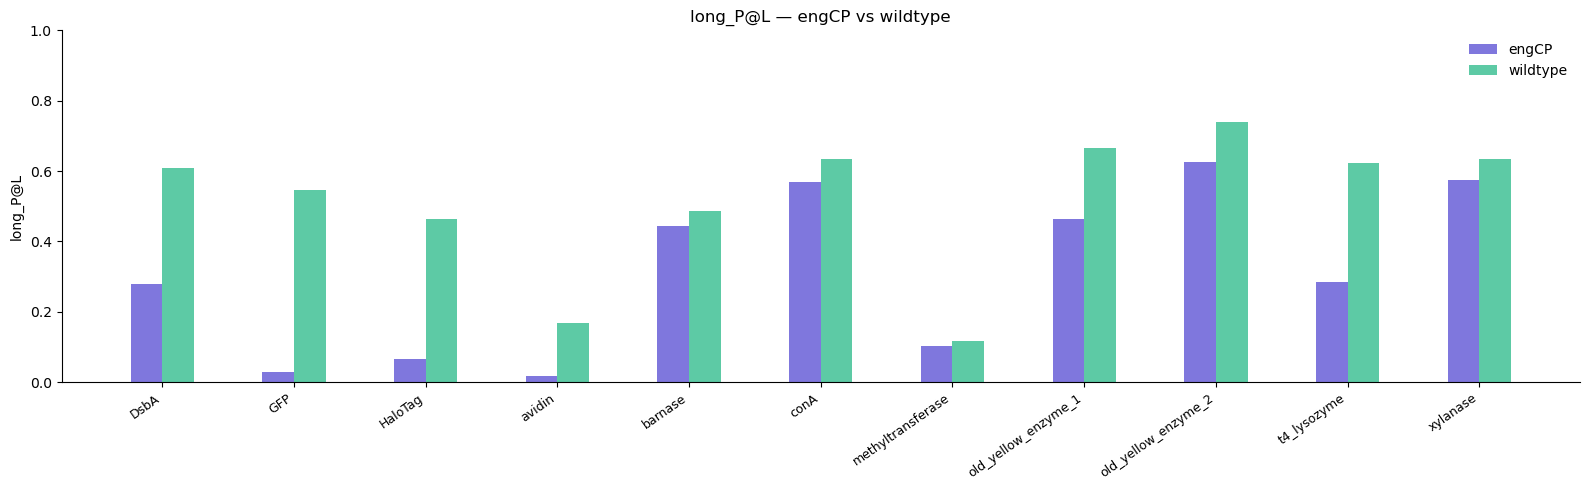

In [16]:
labels = [d.name for d in pair_dirs]

metric = "long_P@L"

engcp_vals = [esm2_results.loc[esm2_results["id"] == k, metric].values[0] for k in pairs]
wt_vals    = [esm2_results.loc[esm2_results["id"] == v, metric].values[0] for v in pairs.values()]

# directory names as labels
labels = [Path(p).name for p in pair_dirs]

x = np.arange(len(labels)) * 0.75
w = 0.18

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - w/2, engcp_vals, width=w, color="#7F77DD", label="engCP")
ax.bar(x + w/2, wt_vals,    width=w, color="#5DCAA5", label="wildtype")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=9)
ax.set_ylim(0, 1)
ax.set_ylabel(metric)
ax.set_title(f"{metric} — engCP vs wildtype")

ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('engCP_long_range_pL.png')
plt.show()

### ESM-2 Predictions

In [ ]:

for name, inputs in sequences.items():
    esm2_batch_labels, esm2_batch_strs, esm2_batch_tokens = esm2_batch_converter([inputs])
    esm2_batch_tokens = esm2_batch_tokens.to(next(esm2.parameters()).device)
    esm2_predictions[name] = esm2.predict_contacts(esm2_batch_tokens)[0].cpu()
    metrics = {"id": name, "model": "ESM-2 (Unsupervised)"}
    metrics.update(evaluate_prediction(esm2_predictions[name], contacts[name]))
    esm2_results.append(metrics)
esm2_results = pd.DataFrame(esm2_results)
display(esm2_results)

In [ ]:
fig, axes = plt.subplots(figsize=(18, 6), ncols=2)
for ax, name in zip(axes, PDB_IDS):
    prediction = esm2_predictions[name]
    target = contacts[name]
    plot_contacts_and_predictions(
        prediction, target, ax=ax, title = lambda prec: f"{name}: Long Range P@L: {100 * prec:0.1f}"
    )
plt.show()

### MSA Transformer Predictions

In [ ]:
msa_transformer, msa_transformer_alphabet = esm.pretrained.esm_msa1b_t12_100M_UR50S()
msa_transformer = msa_transformer.eval().cuda()
msa_transformer_batch_converter = msa_transformer_alphabet.get_batch_converter()

In [ ]:
# Clear up memory
esm2=esm2.to("cpu")
import gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
msa_transformer_predictions = {}
msa_transformer_results = []
for name, inputs in msas.items():
    inputs = greedy_select(inputs, num_seqs=128) # can change this to pass more/fewer sequences
    msa_transformer_batch_labels, msa_transformer_batch_strs, msa_transformer_batch_tokens = msa_transformer_batch_converter([inputs])
    msa_transformer_batch_tokens = msa_transformer_batch_tokens.to(next(msa_transformer.parameters()).device)
    msa_transformer_predictions[name] = msa_transformer.predict_contacts(msa_transformer_batch_tokens)[0].cpu()
    metrics = {"id": name, "model": "MSA Transformer (Unsupervised)"}
    metrics.update(evaluate_prediction(msa_transformer_predictions[name], contacts[name]))
    msa_transformer_results.append(metrics)
msa_transformer_results = pd.DataFrame(msa_transformer_results)
display(msa_transformer_results)

In [ ]:
fig, axes = plt.subplots(figsize=(18, 6), ncols=3)
for ax, name in zip(axes, PDB_IDS):
    prediction = msa_transformer_predictions[name]
    target = contacts[name]
    plot_contacts_and_predictions(
        prediction, target, ax=ax, title = lambda prec: f"{name}: Long Range P@L: {100 * prec:0.1f}"
    )
plt.show()